# Ensemble Empirical Mode Decomposition (EEMD)

**EEMD** is a noise-assisted upgrade of classical EMD.  Instead of sifting the
raw signal once, it sifts an **ensemble** of copies

$$
x^{(i)}(t) = x(t) + w^{(i)}(t),\qquad i=1,\ldots,I,
$$

where each $w^{(i)}$ is a different finite-amplitude white-noise realization,
and defines the “true” IMF as the ensemble mean

$$
\overline{\mathrm{IMF}}_k(t)
= \frac{1}{I}\sum_{i=1}^{I}\mathrm{IMF}_k^{(i)}(t).
$$

The added noise populates the time–frequency plane uniformly and forces EMD’s
dyadic filter-bank behaviour, which largely suppresses **mode mixing** caused
by intermittency.  Averaging cancels the noise, leaving the persistent signal
components.

**Reference**

> Z. Wu and N. E. Huang.  
> *Ensemble Empirical Mode Decomposition: A Noise-Assisted Data Analysis Method.*  
> Advances in Adaptive Data Analysis, 1(1):1–41, 2009.

This notebook uses `pysdkit.EEMD`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import EEMD, EMD
from pysdkit.data import test_emd
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra

print(EEMD())


Ensemble Empirical Mode Decomposition (EEMD)


## 2. Algorithm principles

### 2.1 Mode mixing in plain EMD

When a signal contains **intermittent** high-frequency bursts riding on a
smooth carrier, a single EMD sift often packs both scales into one IMF
(or splits one scale across several IMFs).  Wu & Huang call this
**mode mixing**.

### 2.2 Noise as a uniform reference frame

White noise of finite amplitude fills every scale.  Bits of the signal of a
given scale are then projected onto the corresponding dyadic IMF of that
noisy background.  Because each trial uses an *independent* noise draw, the
noise terms cancel in the ensemble mean while the signal persists.

### 2.3 Formal procedure

1. Choose ensemble size $I$ and noise amplitude $\varepsilon$  
   (in PySDKit: `trials`, `noise_width` × signal range).
2. For $i=1,\ldots,I$: form $x^{(i)}=x+w^{(i)}$ and run full EMD.
3. Align IMFs by order $k$ and average across trials.
4. (Optional) report the residue $r = x - \sum_k \overline{\mathrm{IMF}}_k$.

> **Note.**  Averaging independent EMD runs does **not** guarantee exact
> reconstruction of $x$ (different trials may yield different IMF counts).
> CEEMDAN was later designed to restore completeness — see
> `examples/ceemdan.ipynb`.

## 3. Demo signal: intermittency (mode mixing)

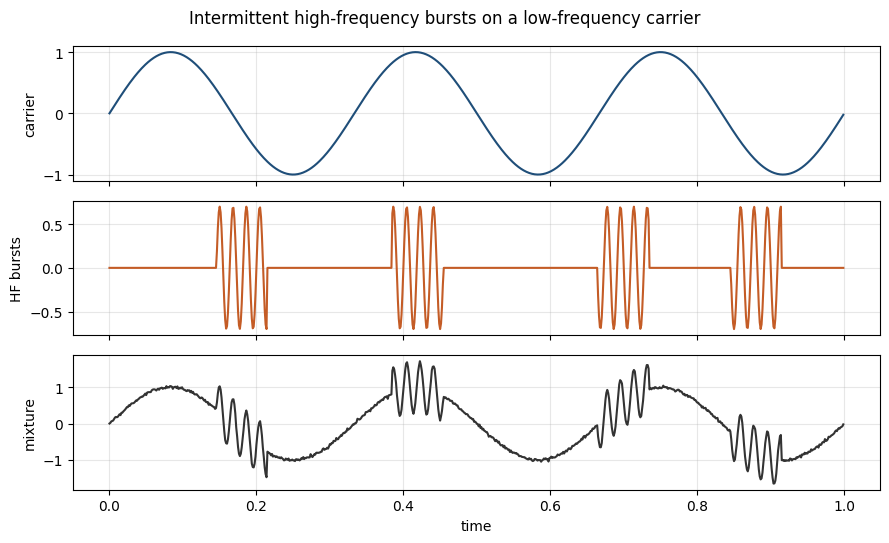

In [2]:
rng = np.random.default_rng(0)
n = 800
t = np.linspace(0.0, 1.0, n, endpoint=False)

carrier = np.sin(2 * np.pi * 3 * t)
bursts = np.zeros_like(t)
for centre in (0.18, 0.42, 0.70, 0.88):
    mask = np.abs(t - centre) < 0.035
    bursts[mask] = 0.7 * np.sin(2 * np.pi * 55 * t[mask])

signal = carrier + bursts + 0.02 * rng.standard_normal(n)

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(t, carrier, color="#1f4e79")
axes[0].set_ylabel("carrier")
axes[1].plot(t, bursts, color="#c45c26")
axes[1].set_ylabel("HF bursts")
axes[2].plot(t, signal, color="0.2")
axes[2].set_ylabel("mixture")
axes[2].set_xlabel("time")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.suptitle("Intermittent high-frequency bursts on a low-frequency carrier")
plt.tight_layout()
plt.show()

## 4. Algorithm workflow visualisation

We illustrate one noise-assisted trial and then the ensemble average.

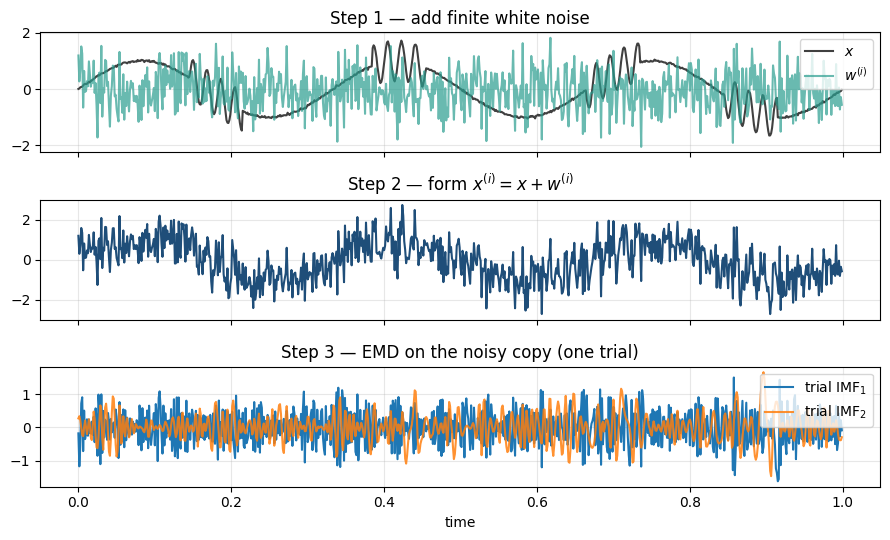

In [3]:
eemd = EEMD(trials=40, noise_width=0.2, max_imfs=4, random_seed=0)

# --- one trial: signal + noise → EMD ---
scale = eemd.noise_width * (np.max(signal) - np.min(signal))
noise = eemd.generate_noise(scale=scale, size=n)
noisy = signal + noise
trial_imfs = EMD(max_imfs=4).fit_transform(noisy, time=t)

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(t, signal, label="$x$", color="0.25")
axes[0].plot(t, noise, label="$w^{(i)}$", alpha=0.7, color="#2a9d8f")
axes[0].legend(loc="upper right")
axes[0].set_title("Step 1 — add finite white noise")
axes[1].plot(t, noisy, color="#1f4e79")
axes[1].set_title(r"Step 2 — form $x^{(i)}=x+w^{(i)}$")
axes[2].plot(t, trial_imfs[0], label="trial IMF$_1$")
if trial_imfs.shape[0] > 1:
    axes[2].plot(t, trial_imfs[1], label="trial IMF$_2$", alpha=0.85)
axes[2].legend(loc="upper right")
axes[2].set_title("Step 3 — EMD on the noisy copy (one trial)")
axes[2].set_xlabel("time")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Full EEMD decomposition

ensemble IMFs: (5, 800)
ensemble counts per order: [40, 40, 40, 40, 40]
max |x - (sum IMFs + residue)|: 1.3877787807814457e-17
reconstruction error of ensemble mean alone: 0.13016445161292284


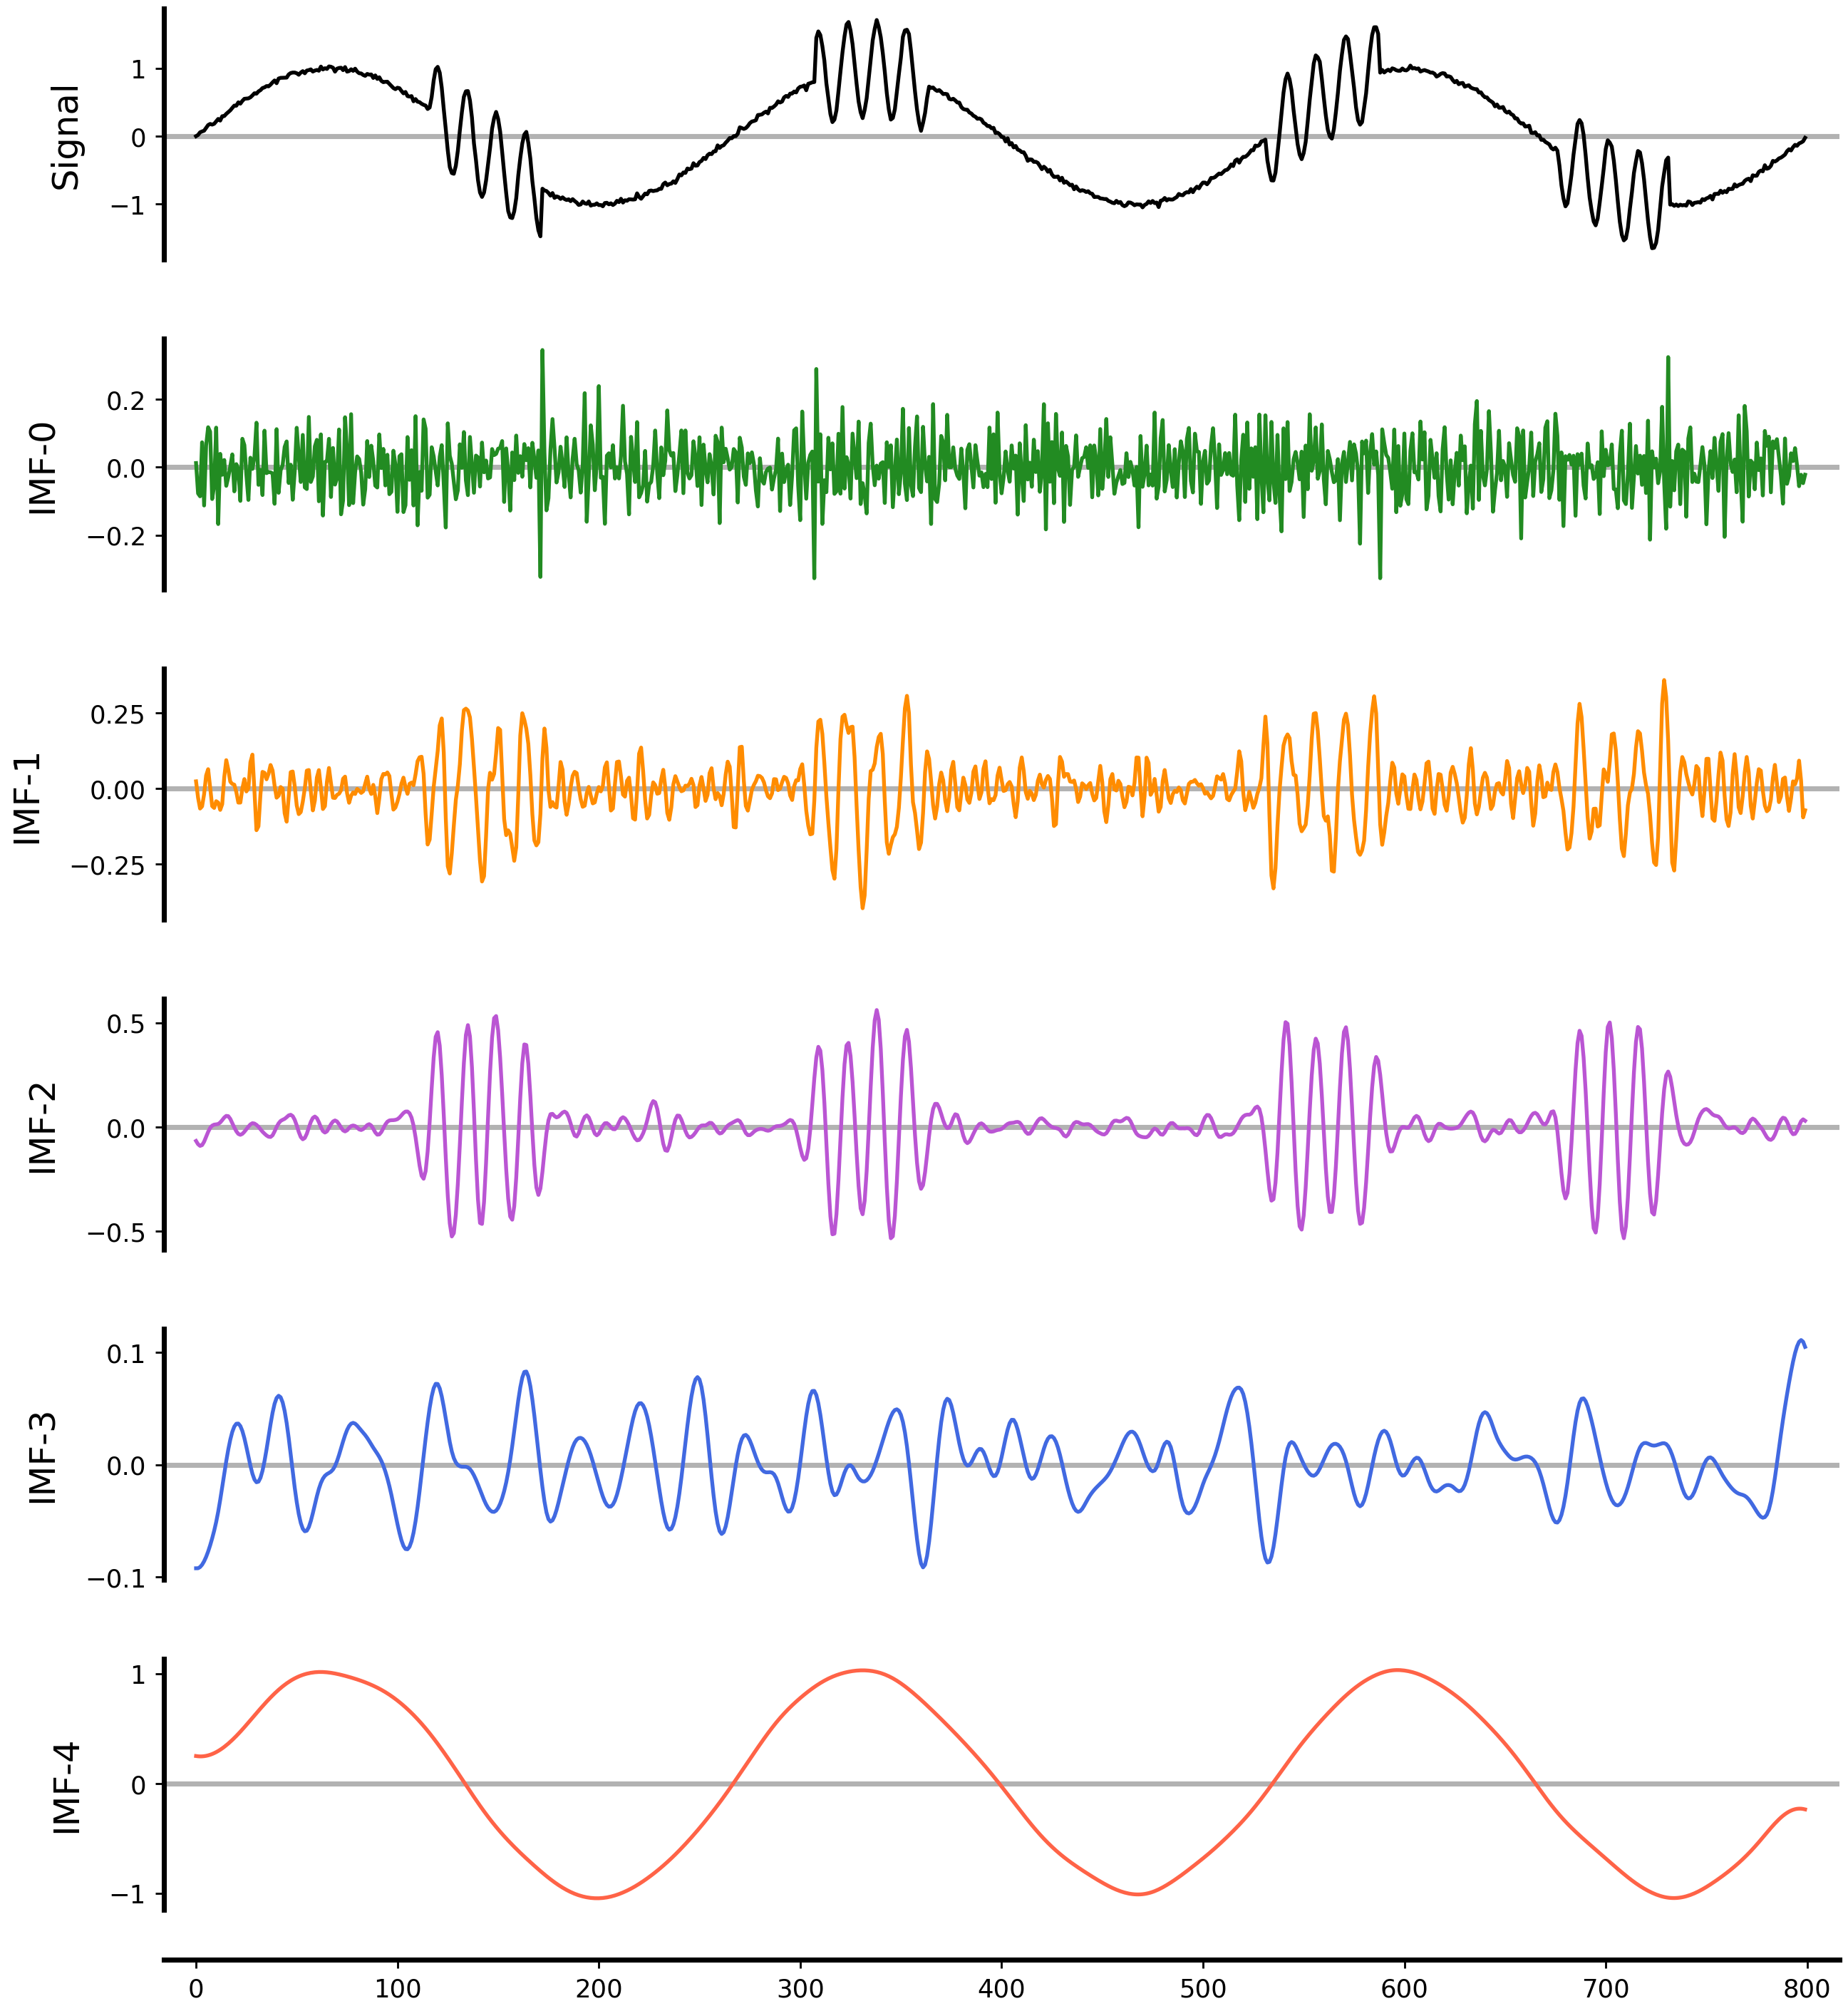

In [4]:
imfs = eemd.fit_transform(signal, time=t)
imfs_mean, residue = eemd.get_imfs_and_residue()

print("ensemble IMFs:", imfs.shape)
print("ensemble counts per order:", eemd.ensemble_count())
print(
    "max |x - (sum IMFs + residue)|:",
    float(np.max(np.abs(signal - (imfs.sum(0) + residue)))),
)
print(
    "reconstruction error of ensemble mean alone:",
    float(np.linalg.norm(signal - imfs.sum(0)) / np.linalg.norm(signal)),
)

plot_IMFs(signal, imfs)
plt.show()

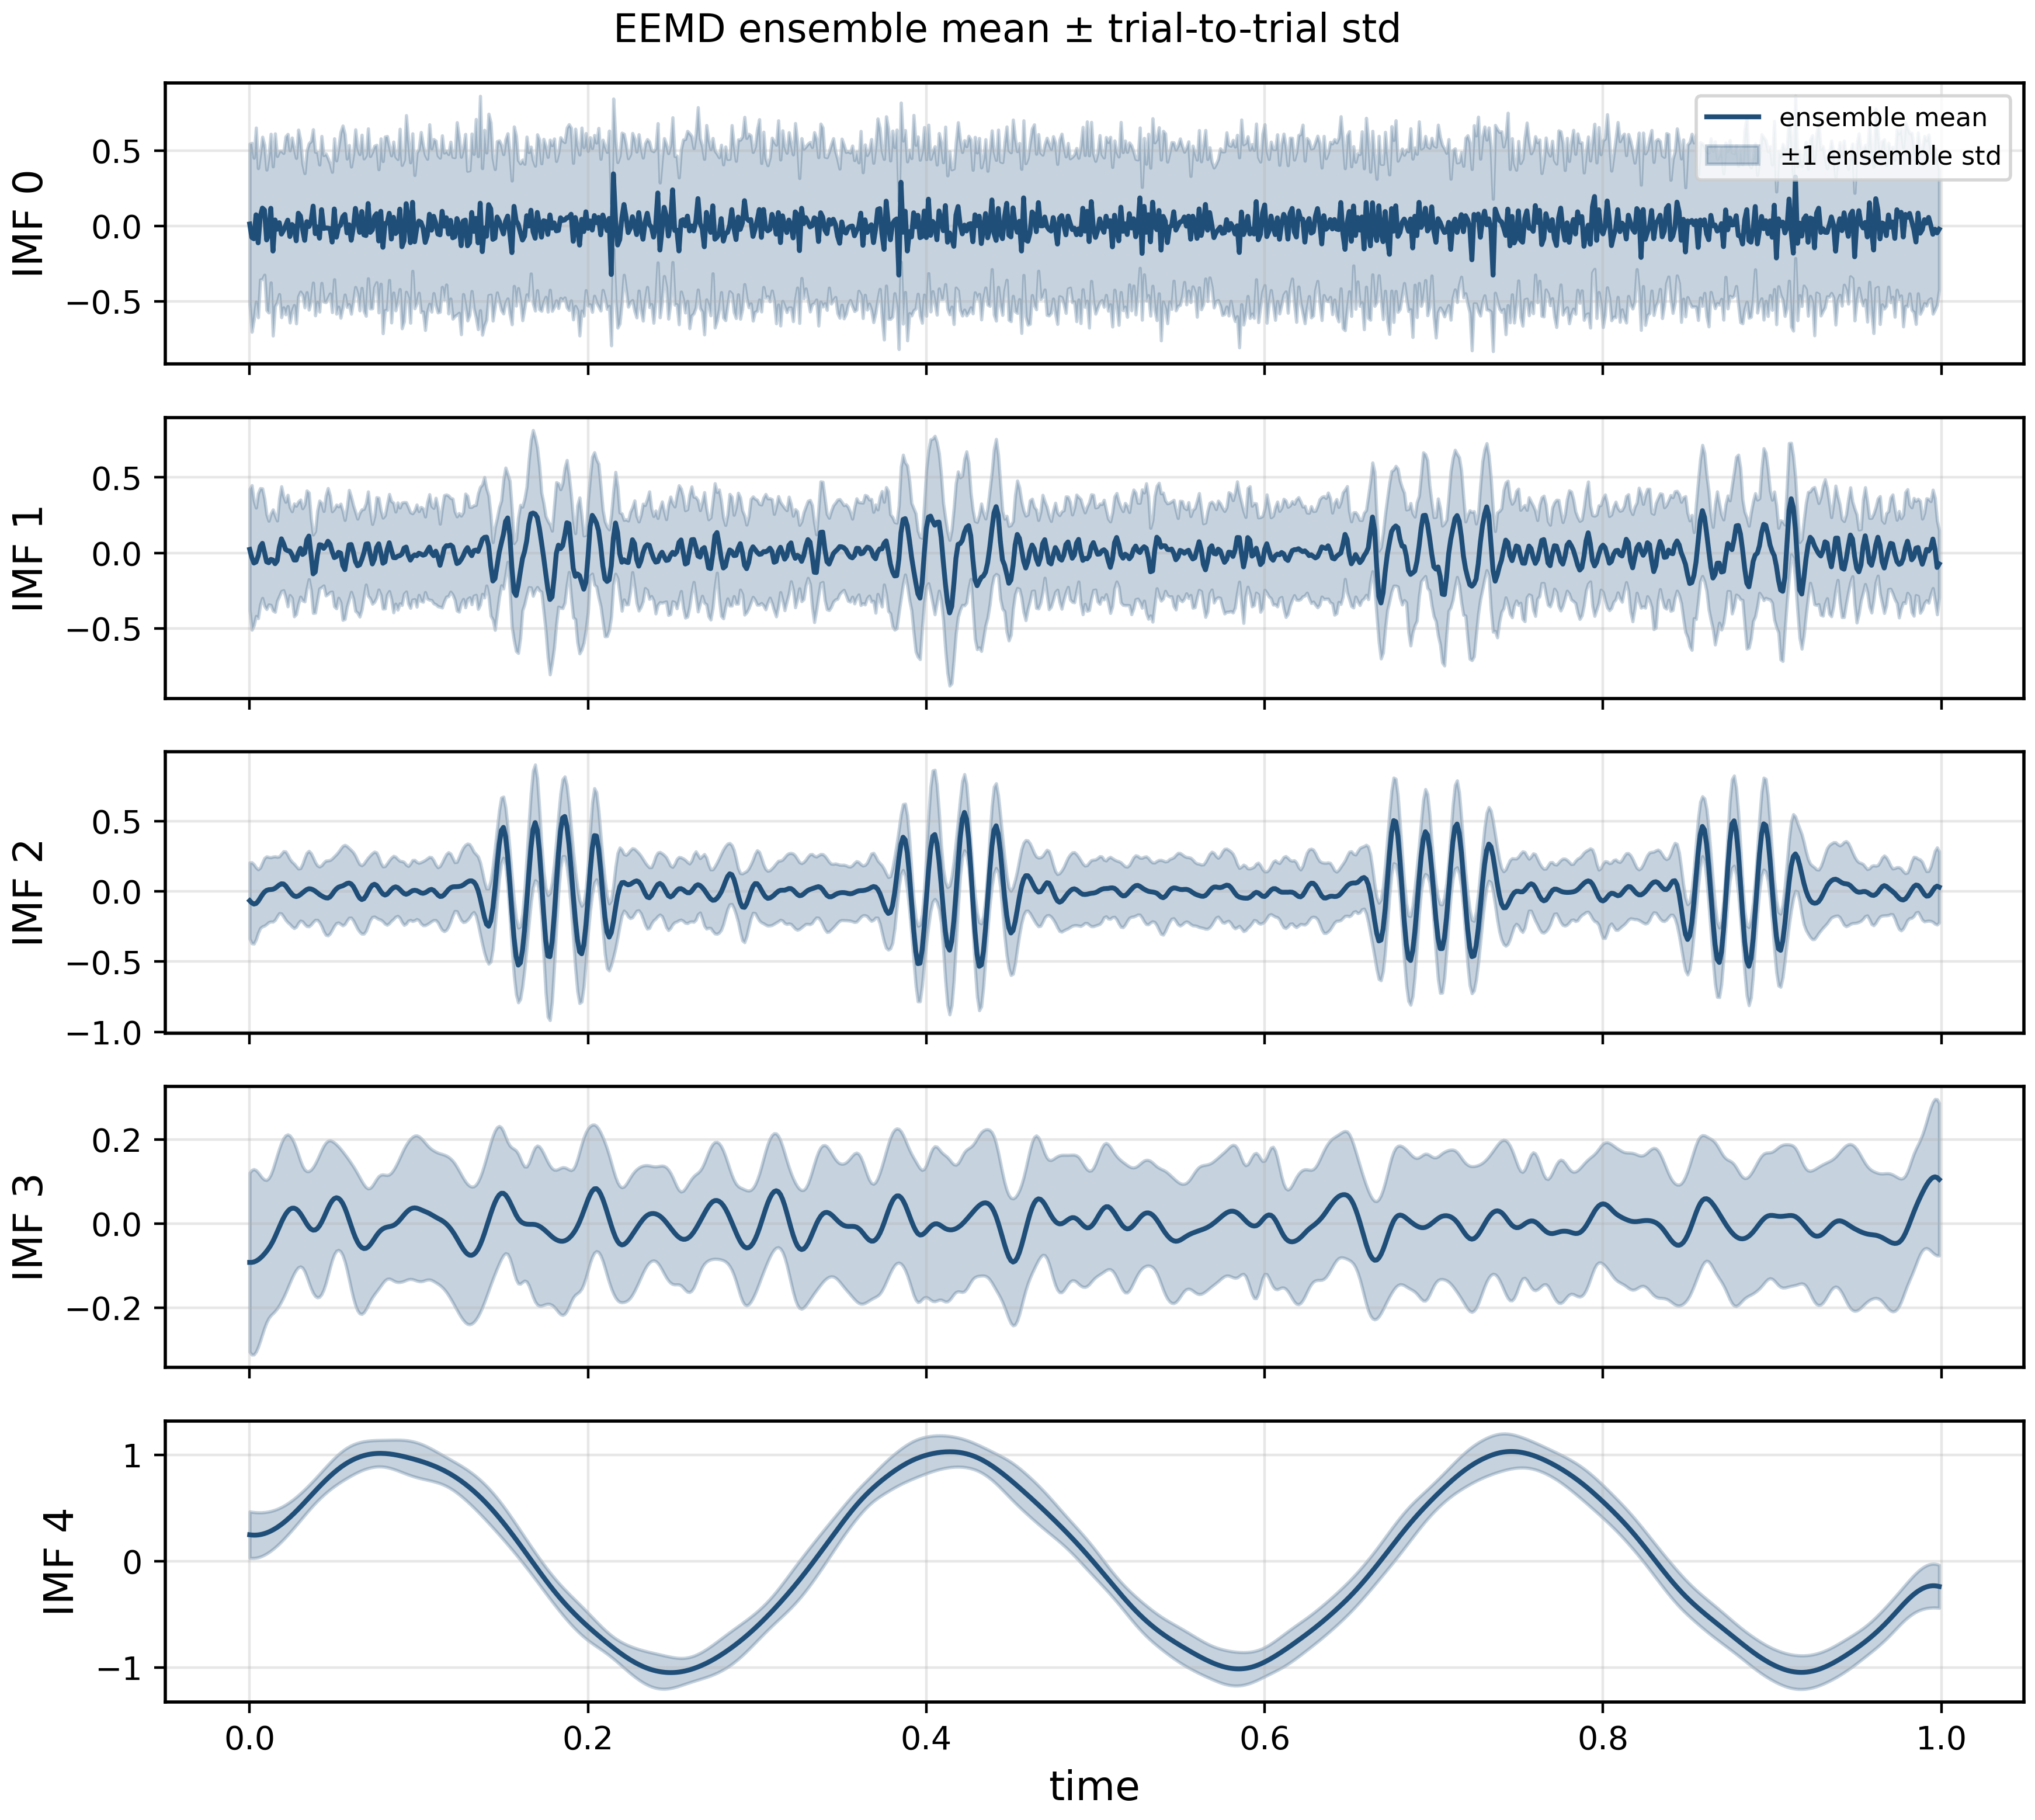

In [5]:
# Ensemble variability: std across trials for each IMF order
std = eemd.ensemble_std()

fig, axes = plt.subplots(
    imfs.shape[0], 1, figsize=(9, 1.6 * imfs.shape[0]), sharex=True
)
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(t, imfs[k], color="#1f4e79", label="ensemble mean")
    ax.fill_between(
        t,
        imfs[k] - std[k],
        imfs[k] + std[k],
        color="#1f4e79",
        alpha=0.25,
        label=r"$\pm 1$ ensemble std",
    )
    ax.set_ylabel(f"IMF {k}")
    ax.grid(True, alpha=0.3)
    if k == 0:
        ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time")
plt.suptitle("EEMD ensemble mean ± trial-to-trial std")
plt.tight_layout()
plt.show()

## 6. Comparison with plain EMD

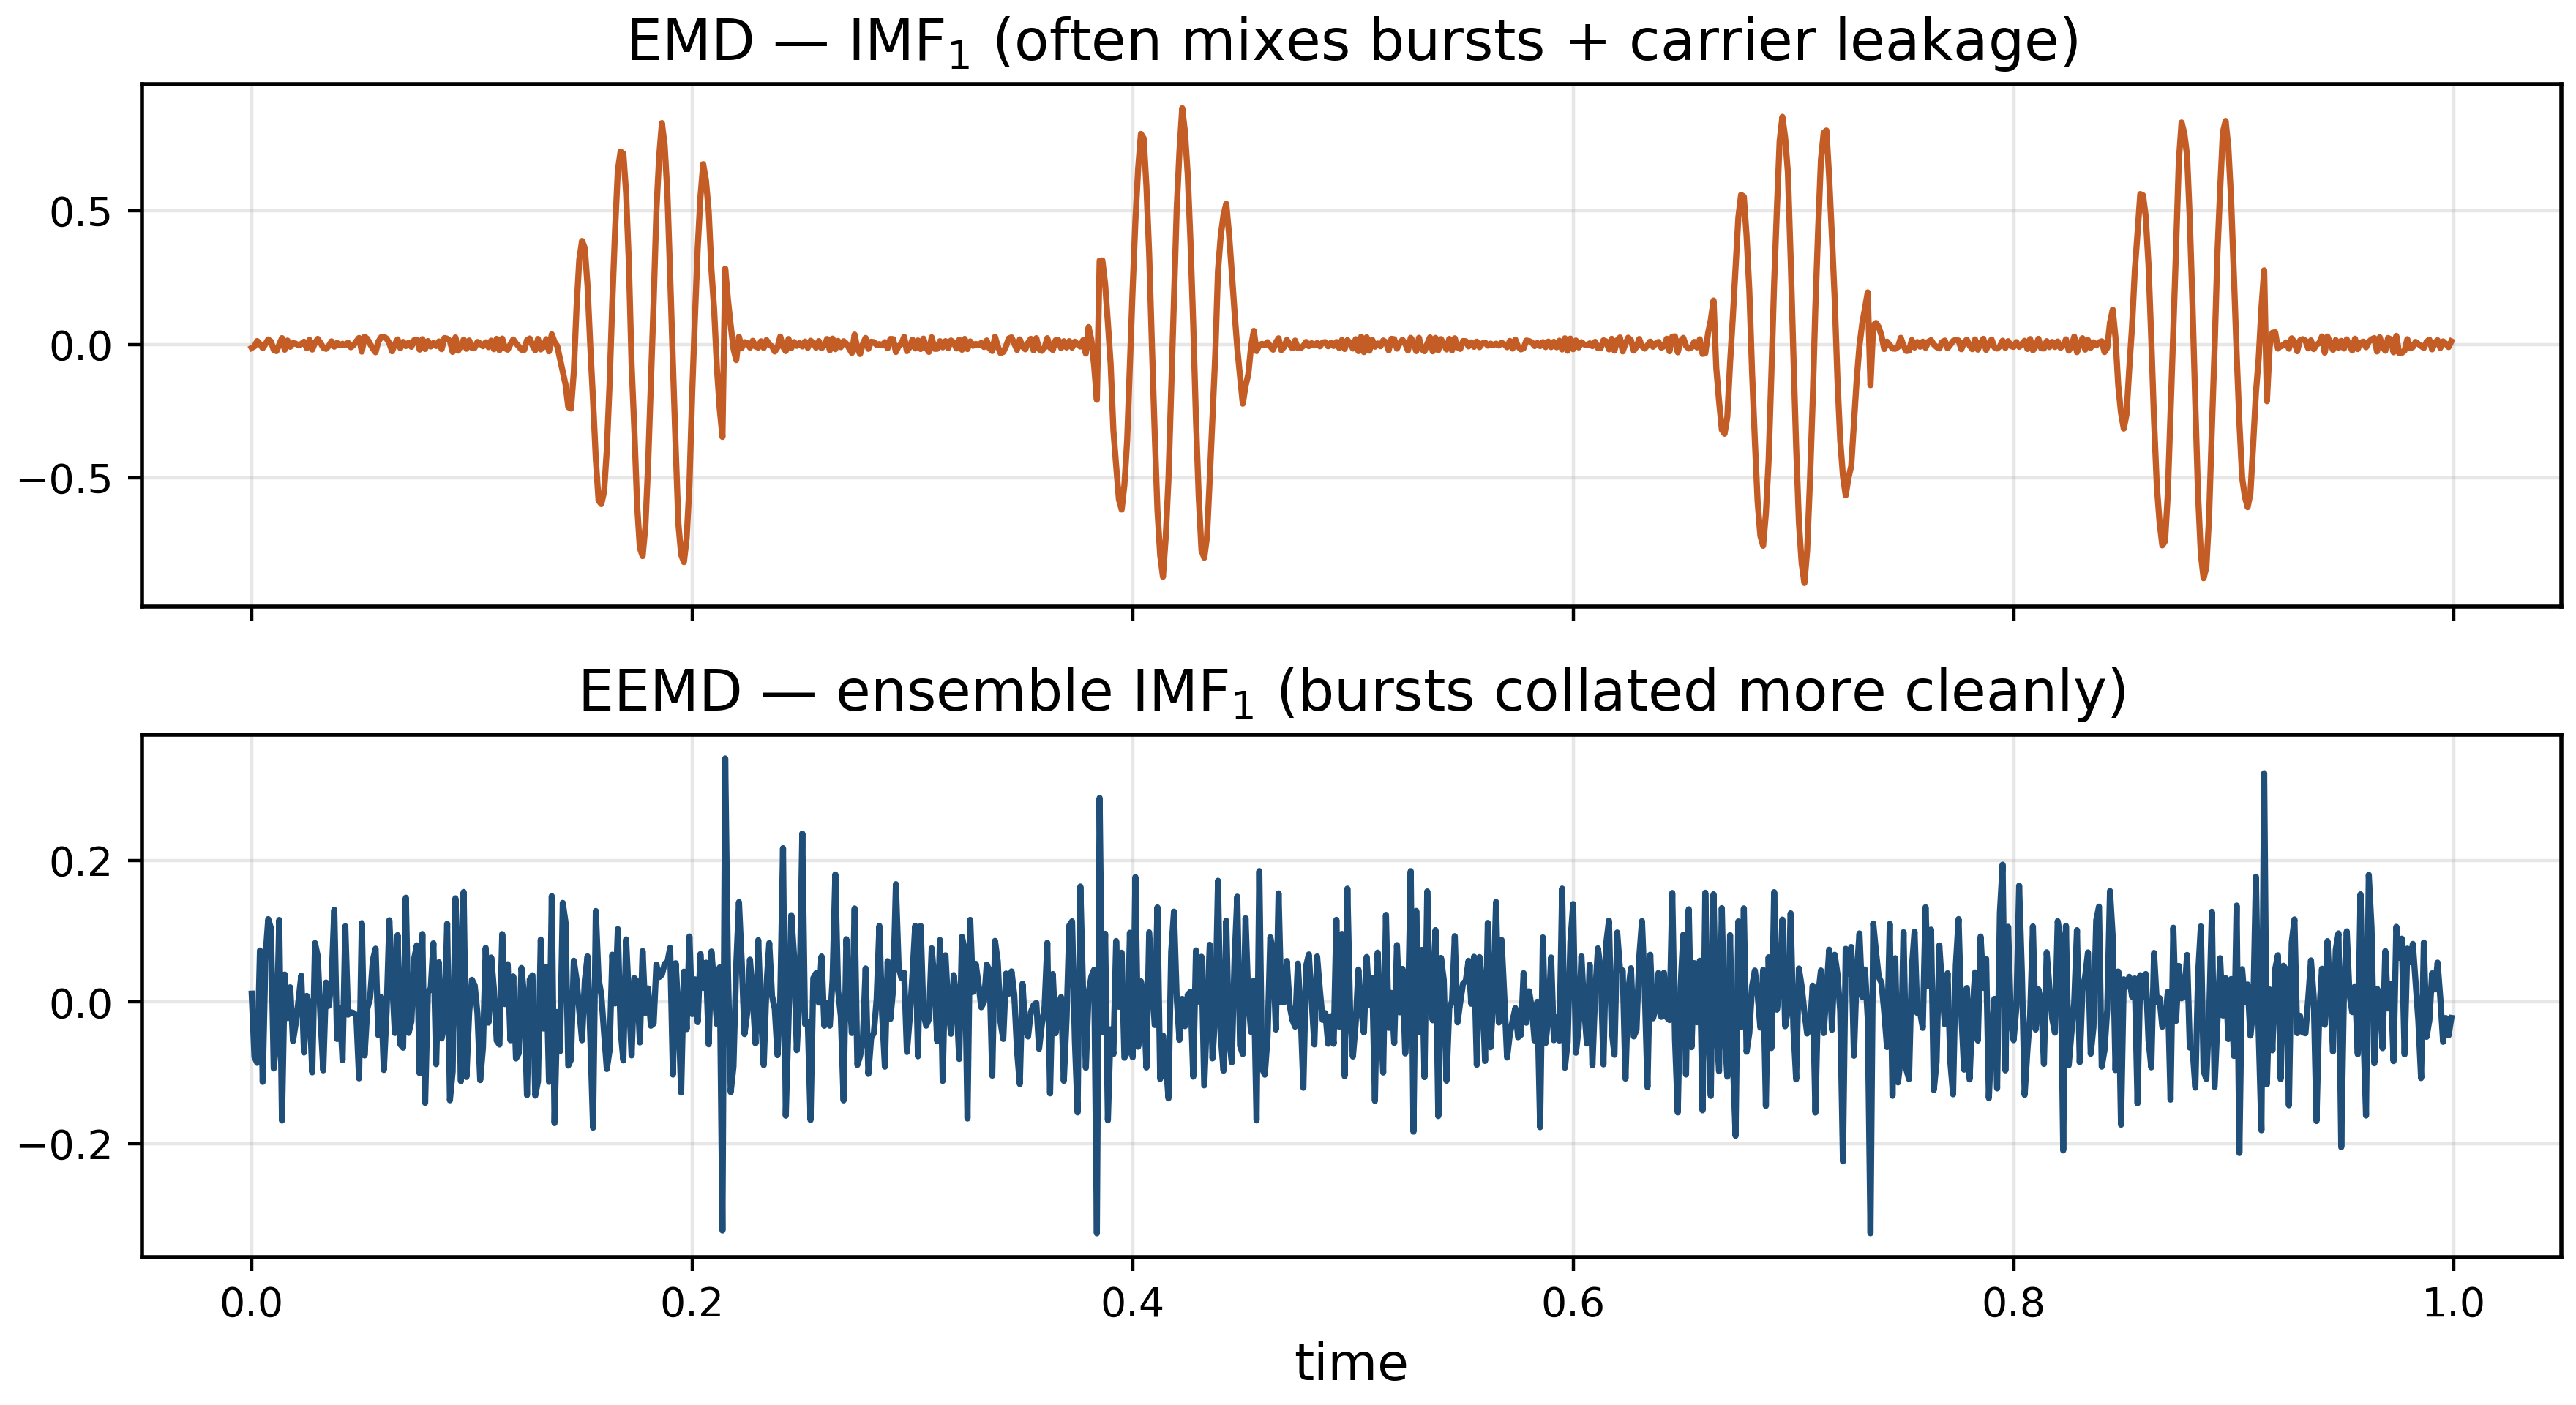

run classic


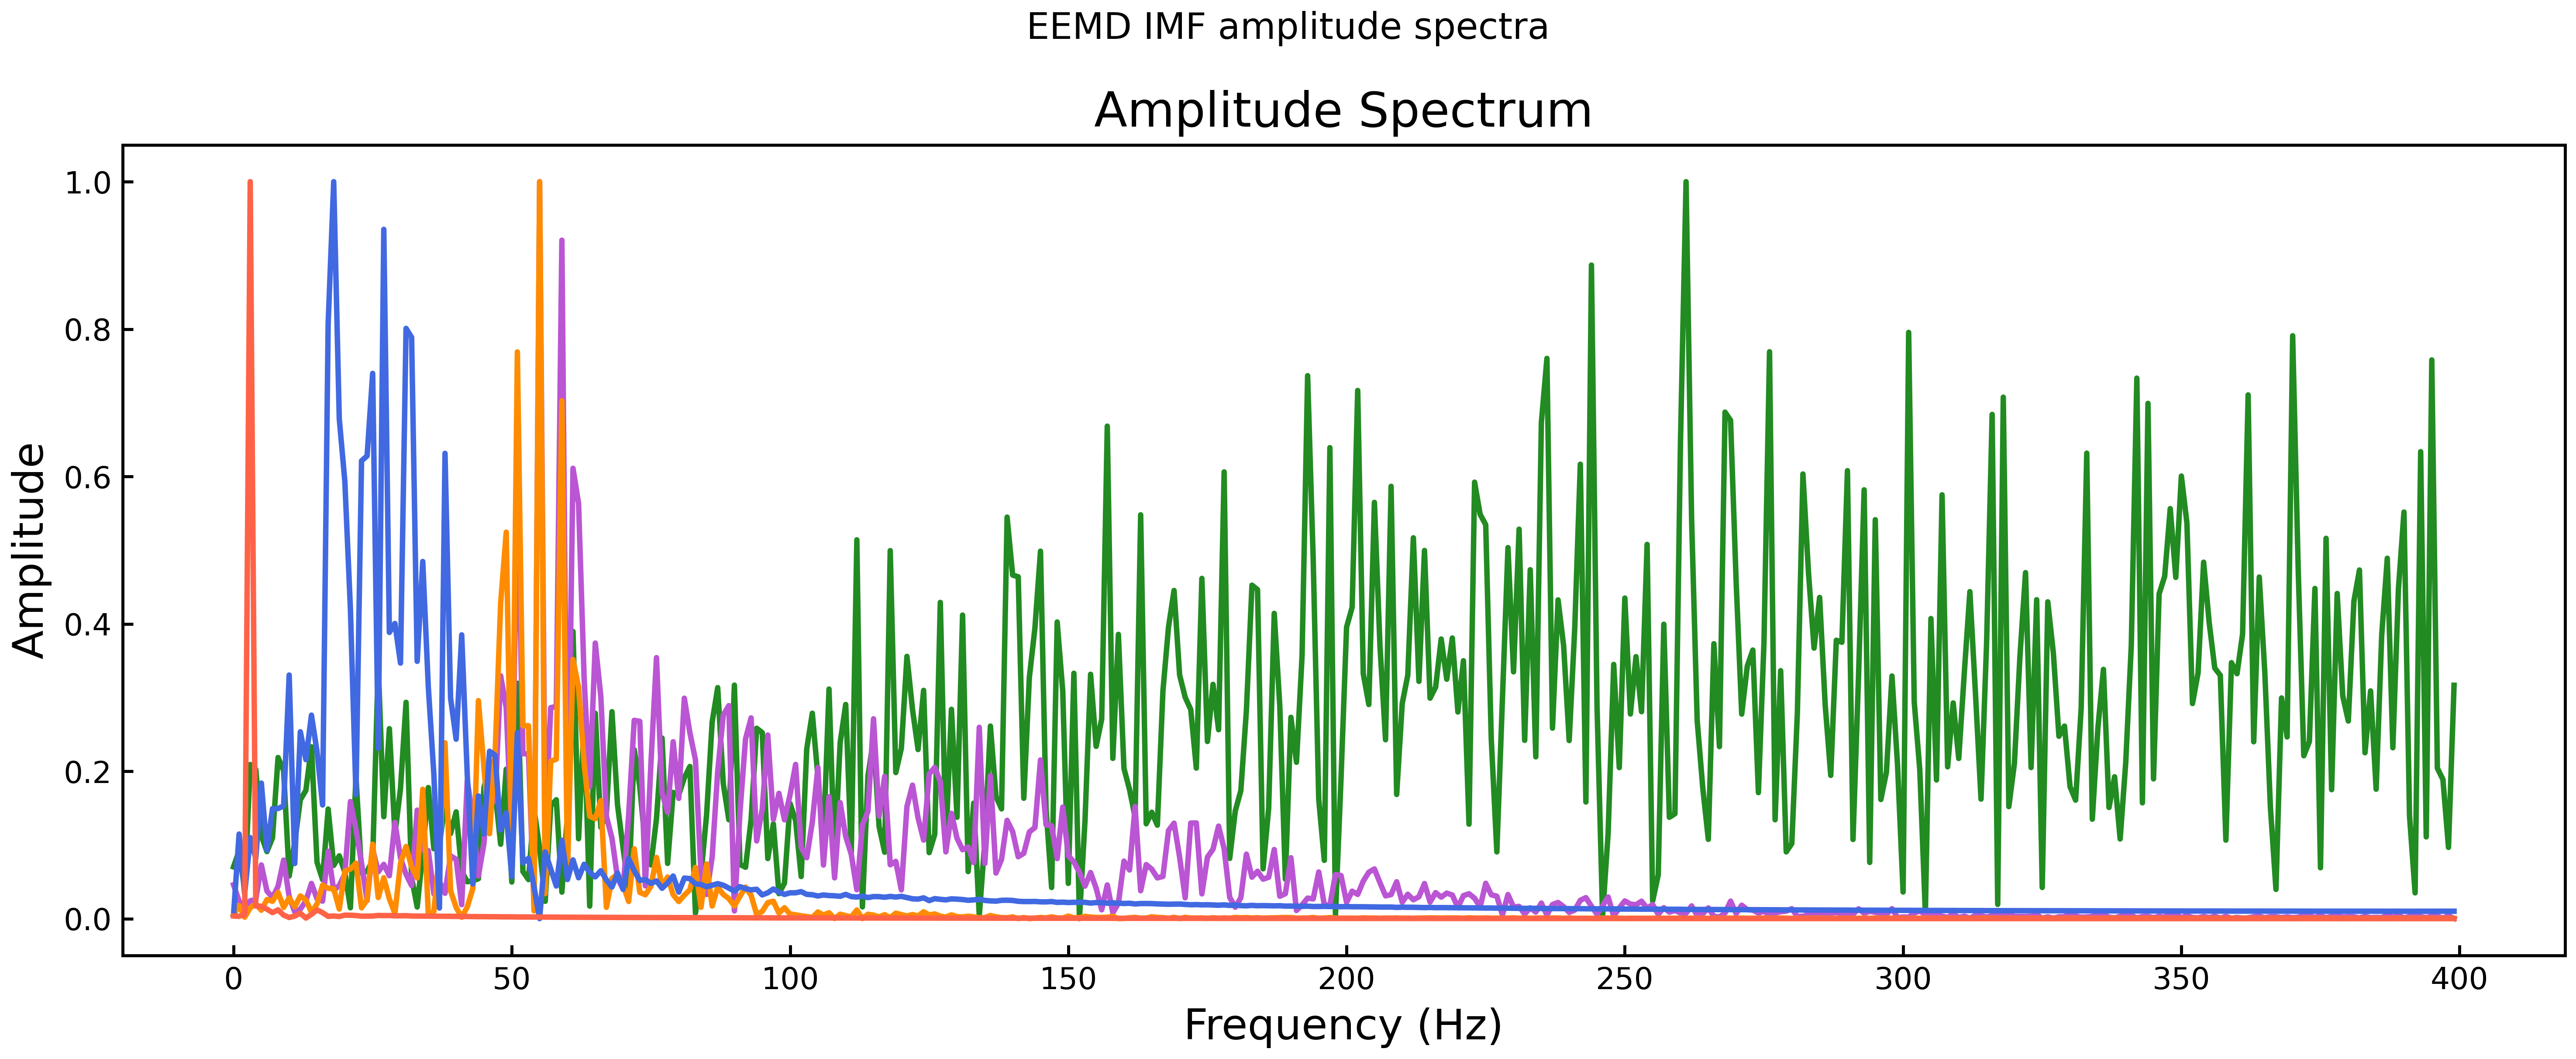

In [6]:
emd_imfs = EMD(max_imfs=4).fit_transform(signal, time=t)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(t, emd_imfs[0], color="#c45c26")
axes[0].set_title("EMD — IMF$_1$ (often mixes bursts + carrier leakage)")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t, imfs[0], color="#1f4e79")
axes[1].set_title("EEMD — ensemble IMF$_1$ (bursts collated more cleanly)")
axes[1].set_xlabel("time")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_IMFs_amplitude_spectra(imfs)
plt.suptitle("EEMD IMF amplitude spectra")
plt.tight_layout()
plt.show()

## 7. Effect of ensemble size $I$

Wu & Huang emphasise that **enough trials** are needed for the noise to cancel.
Below we track the mean ensemble std of IMF$_1$ versus $I$.

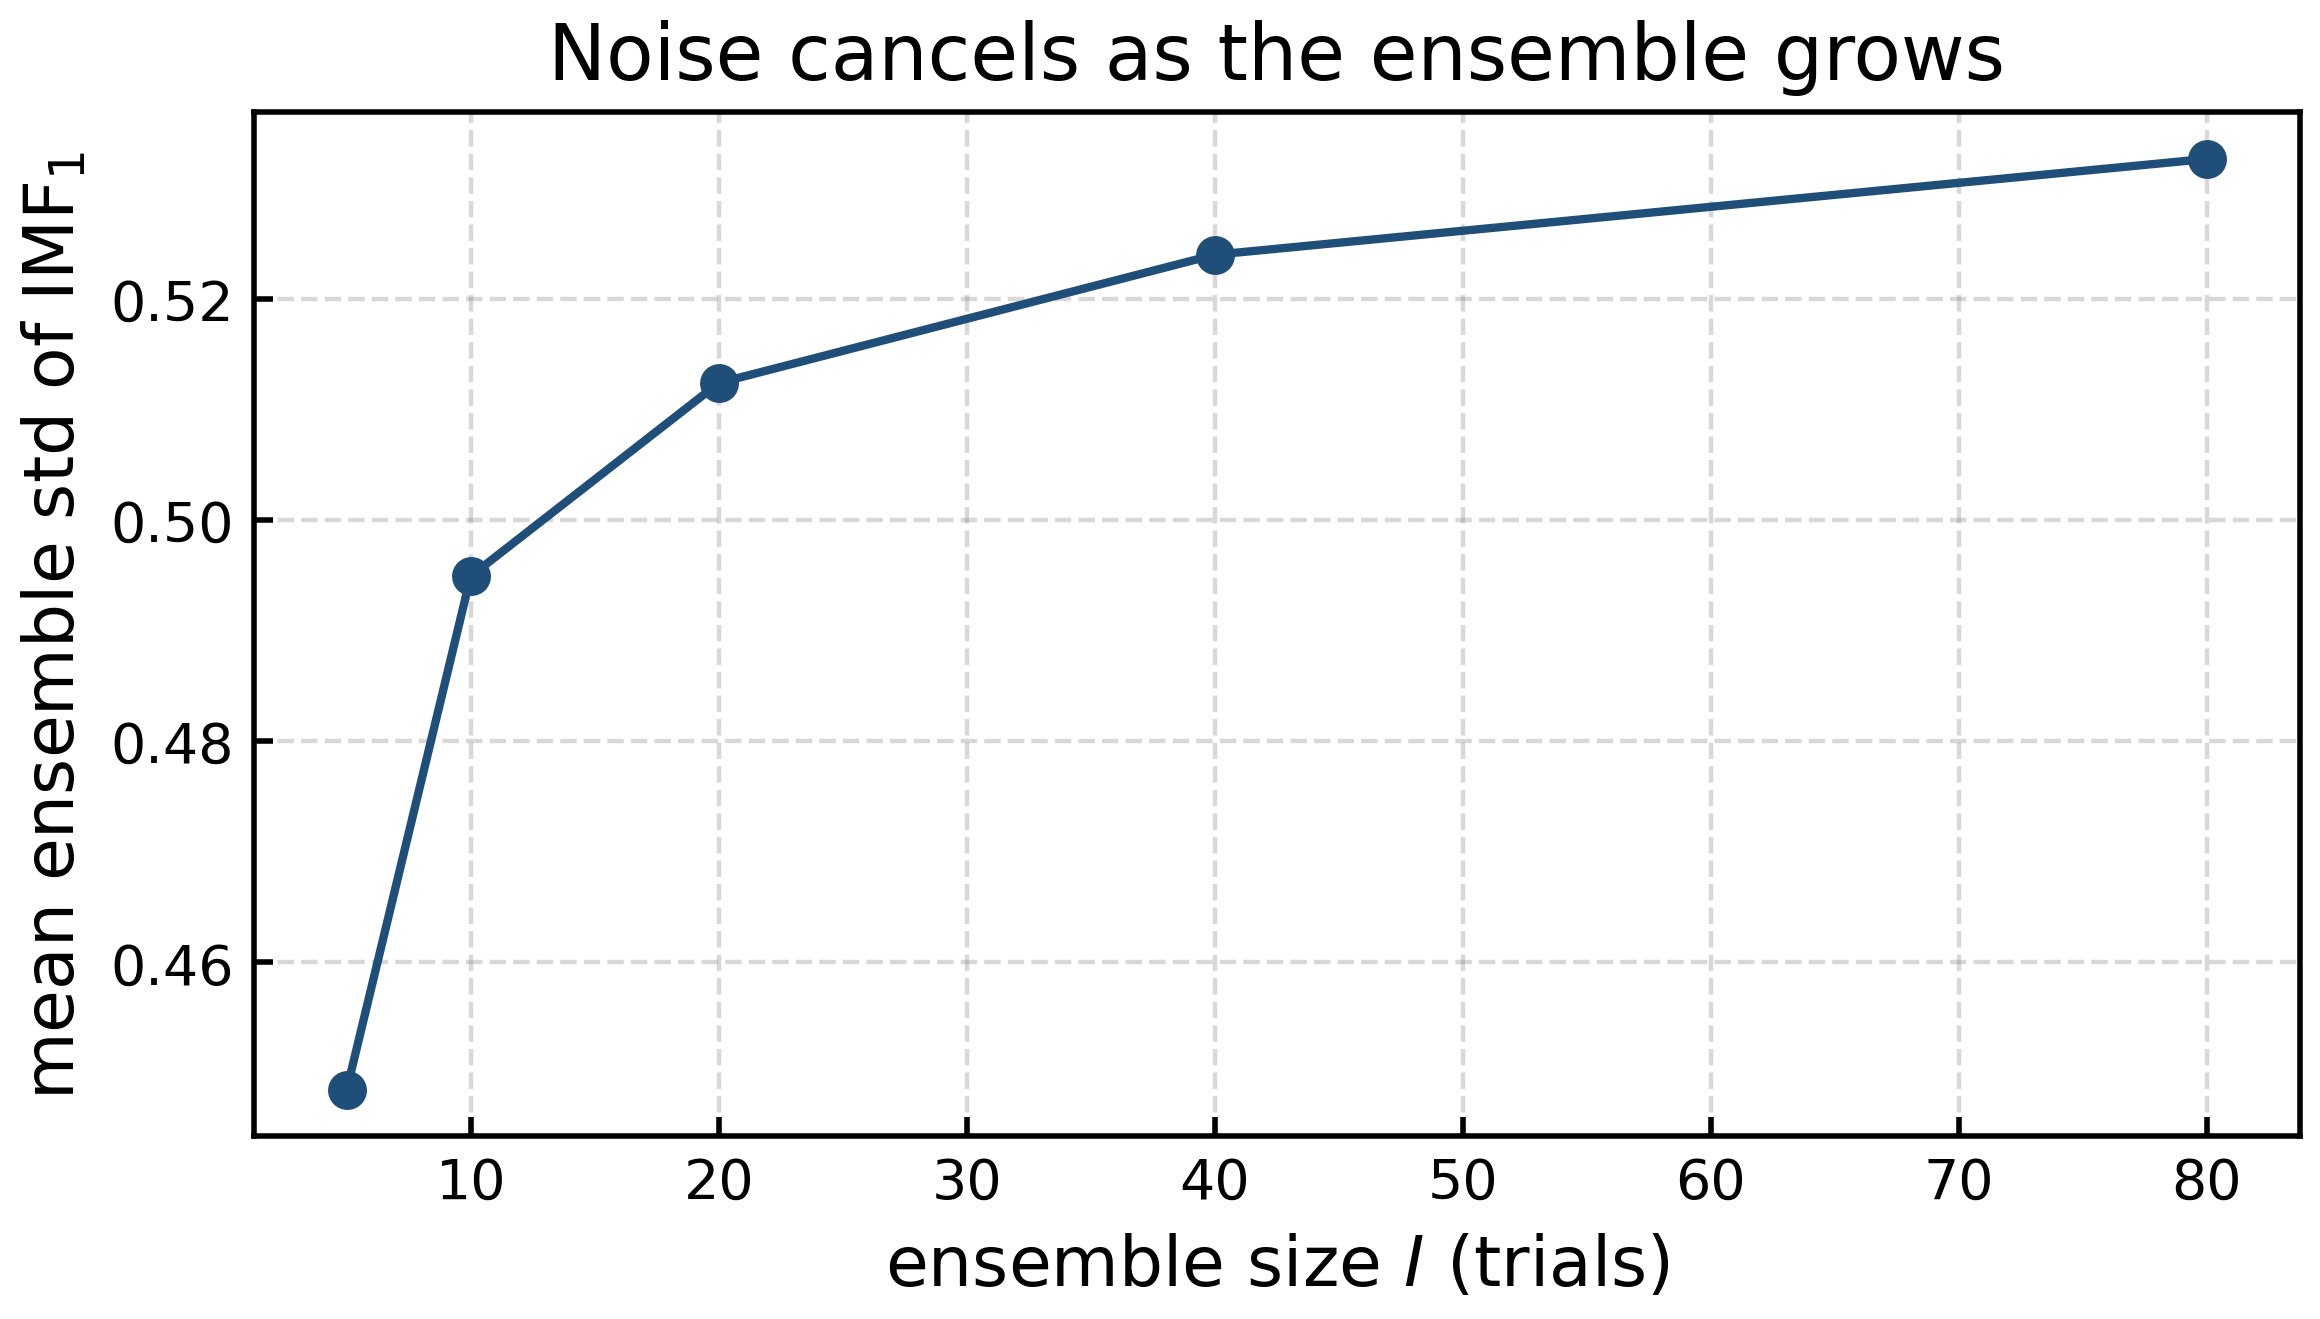

In [7]:
trial_grid = [5, 10, 20, 40, 80]
mean_std = []
for I in trial_grid:
    model = EEMD(trials=I, noise_width=0.2, max_imfs=3, random_seed=0)
    model.fit_transform(signal, time=t)
    mean_std.append(float(np.mean(model.ensemble_std()[0])))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(trial_grid, mean_std, "o-", color="#1f4e79")
ax.set_xlabel("ensemble size $I$ (trials)")
ax.set_ylabel(r"mean ensemble std of IMF$_1$")
ax.set_title("Noise cancels as the ensemble grows")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. API summary

```python
from pysdkit import EEMD

eemd = EEMD(trials=100, noise_width=0.05, max_imfs=4, random_seed=42)
IMFs = eemd.fit_transform(signal)          # (K, N) ensemble-mean IMFs
IMFs, residue = eemd.get_imfs_and_residue()
std = eemd.ensemble_std()                  # trial-to-trial variability
```

## 9. Takeaways

- EEMD = many noisy EMD runs + average → mitigates mode mixing.
- Noise amplitude must be **finite** (not vanishing) to populate scales.
- Larger `trials` shrinks residual ensemble noise (std ↓).
- Reconstruction of $x$ from the ensemble mean alone is approximate;
  keep the stored `residue`, or switch to **CEEMDAN** for completeness.